# Data 

### Data intake, formatting, and cleaning 

```
"if i could open my arms
and span the length of the isle of manhattan
id bring it to where you are
making a lake of the east river and hudson" - death cab for cutie
```

**Summary of dataframes**

Descriptions included below or in report

| Dataframe           | Origin | 
| --------            | -------- | 
| subway_pre_df_jun   | downloaded   |
| subway_pre_df_aug   | downloaded   |
| subway_pre_df_oct   | downloaded  | 
| subway_pre_df       | Compiled from three pre sets   |
| df                  | pre and post stacked   |
| df_rush             | df filtered for |
| df_daily            | df_rush aggregated by day |
| df_weekly           | df_rush aggregated by week |
| df_queens           | df filtered by station then aggregated by day |
| weather_df          | downloaded|


In [ ]:
setwd("/Users/Local/statsproject")

source("src/functions_and_things.r")

load_libraries()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 


Warning message:
“package ‘zoo’ was built under R version 4.5.2”

Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Warning message:
“package ‘modelsummary’ was built under R version 4.5.2”
Warning message:
“package ‘fixest’ was built under R version

## Pre polic data

https://data.ny.gov/Transportation/MTA-Subway-Hourly-Ridership-2020-2024/wujg-7c2s/about_data

June 1, 2024-December 31, 2024

* `subway_pre_df_jun` - June 1, 2024 - July 31, 2024
* `subway_pre_df_aug` - August 1, 2024 - September 31, 2024
* `subway_pre_df_oct` - October 1, 2024 - December 31, 2024

In [3]:
subway_pre_df_jun = read.csv("/Users/Local/statsproject/data/ignore/MTA_Jun2024_Subway_Hourly.csv")

subway_pre_df_aug = read.csv("/Users/Local/statsproject/data/ignore/MTA_Aug2024_Subway_Hourly.csv")

subway_pre_df_oct = read.csv("/Users/Local/statsproject/data/ignore/MTA_Oct2024_Subway_Hourly.csv")

In [4]:
subway_pre_df = rbind(subway_pre_df_oct, 
                      subway_pre_df_aug, 
                      subway_pre_df_jun)

subway_pre_df |> 
    select(transit_timestamp, station_complex, borough, ridership) -> subway_pre_df

nrow(subway_pre_df) == (nrow(subway_pre_df_aug) + nrow(subway_pre_df_jun) + nrow(subway_pre_df_oct))

[1] TRUE

In [5]:
head(subway_pre_df)

,transit_timestamp,station_complex,borough,ridership
,<chr>,<chr>,<chr>,<chr>
1,10/05/2024 09:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,86
2,12/07/2024 07:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,30
3,10/27/2024 04:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,32
4,11/17/2024 11:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,2
5,11/03/2024 07:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,8
6,10/12/2024 03:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,32


## Post policy data

January 1, 2025 - December 31, 2025

* `subway_post_df` - January 01, 2025 - Decemeber 31, 2025

In [6]:
subway_post_df <- read.csv("data/ignore/MTA_Jan2025.csv")

summary(subway_post_df)

 transit_timestamp  station_complex      borough           ridership        
 Length:28829731    Length:28829731    Length:28829731    Length:28829731   
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  

In [7]:
head(subway_post_df)

,transit_timestamp,station_complex,borough,ridership
,<chr>,<chr>,<chr>,<chr>
1,01/01/2025 12:00:00 AM,"Broad St (J,Z)",Manhattan,2
2,01/01/2025 12:00:00 AM,Graham Av (L),Brooklyn,8
3,01/01/2025 12:00:00 AM,Livonia Av (L),Brooklyn,1
4,01/01/2025 12:00:00 AM,"Canal St (A,C,E)",Manhattan,171
5,01/01/2025 12:00:00 AM,"High St (A,C)",Brooklyn,59
6,01/01/2025 12:00:00 AM,57 St (M),Manhattan,21


## Stacking pre and post datasets 

June 2024 - June 2025

24 million rows

In [8]:
subway_post_df |> select(transit_timestamp, station_complex, borough, ridership) -> subway_post_df

In [9]:
head(subway_pre_df)

head(subway_post_df)

,transit_timestamp,station_complex,borough,ridership
,<chr>,<chr>,<chr>,<chr>
1,10/05/2024 09:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,86
2,12/07/2024 07:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,30
3,10/27/2024 04:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,32
4,11/17/2024 11:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,2
5,11/03/2024 07:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,8
6,10/12/2024 03:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,32


,transit_timestamp,station_complex,borough,ridership
,<chr>,<chr>,<chr>,<chr>
1,01/01/2025 12:00:00 AM,"Broad St (J,Z)",Manhattan,2
2,01/01/2025 12:00:00 AM,Graham Av (L),Brooklyn,8
3,01/01/2025 12:00:00 AM,Livonia Av (L),Brooklyn,1
4,01/01/2025 12:00:00 AM,"Canal St (A,C,E)",Manhattan,171
5,01/01/2025 12:00:00 AM,"High St (A,C)",Brooklyn,59
6,01/01/2025 12:00:00 AM,57 St (M),Manhattan,21


In [10]:
df <- rbind(subway_pre_df, subway_post_df)

before_nrow <- nrow(df)

In [11]:
nrow(df) == nrow(subway_post_df) + nrow(subway_pre_df)

[1] TRUE

In [12]:
df = distinct(df)  # remove duplicates in case i messed dates up

In [13]:
after_nrow <- nrow(df)

paste0("Before, in the combined set, there were ", before_nrow, " rows. After removing duplicates there were ", after_nrow )
paste(before_nrow - after_nrow, "rows were removed")

[1] "Before, in the combined set, there were 43683565 rows. After removing duplicates there were 36332733"

[1] "7350832 rows were removed"

segment, failsafe

In [14]:
write.csv(df, "data/ignore/raw_hourly.csv")

reload here to avoid running all, will still take foreveer (50 seconds to reload data)

In [15]:
df <- read.csv("data/ignore/raw_hourly.csv")

In [16]:
# ref 1 , ref 2
df |> mutate(
        ridership = as.numeric(ridership),
        transit_timestamp = trimws(transit_timestamp),
        datetime = mdy_hms(transit_timestamp),
        date = as.Date(datetime),
        time = format(datetime, "%H:%M:%S")) -> df

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `ridership = as.numeric(ridership)`.
Caused by warning:
! NAs introduced by coercion”


In [17]:
head(df)

,X,transit_timestamp,station_complex,borough,ridership,datetime,date,time
,<int>,<chr>,<chr>,<chr>,<dbl>,<dttm>,<date>,<chr>
1,1,10/05/2024 09:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,86,2024-10-05 21:00:00,2024-10-05,21:00:00
2,2,12/07/2024 07:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,30,2024-12-07 19:00:00,2024-12-07,19:00:00
3,3,10/27/2024 04:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,32,2024-10-27 16:00:00,2024-10-27,16:00:00
4,4,11/17/2024 11:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,2,2024-11-17 23:00:00,2024-11-17,23:00:00
5,5,11/03/2024 07:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,8,2024-11-03 19:00:00,2024-11-03,19:00:00
6,6,10/12/2024 03:00:00 PM,"Astoria-Ditmars Blvd (N,W)",Queens,32,2024-10-12 15:00:00,2024-10-12,15:00:00


In [18]:
# time im calling rush hour referenced from the MA south shore breakdown lane travel signs
df |> 
    filter(time >= "07:0:00" & time <= "11:00:00") |>
    select(ridership, date, station_complex, borough) |>
    mutate(ridership = as.integer(ridership),
           day = weekdays(as.Date(date)))|> 
    filter(!day %in% c("Saturday", "Sunday")) -> df_rush 

In [19]:
head(df_rush)

,ridership,date,station_complex,borough,day
,<int>,<date>,<chr>,<chr>,<chr>
1,6,2024-10-18,"Astoria-Ditmars Blvd (N,W)",Queens,Friday
2,30,2024-12-12,"Astoria-Ditmars Blvd (N,W)",Queens,Thursday
3,848,2024-11-04,"Astoria-Ditmars Blvd (N,W)",Queens,Monday
4,55,2024-11-22,"Astoria-Ditmars Blvd (N,W)",Queens,Friday
5,2,2024-11-06,"Astoria-Ditmars Blvd (N,W)",Queens,Wednesday
6,235,2024-12-16,"Astoria-Ditmars Blvd (N,W)",Queens,Monday


In [20]:
df_rush |> 
    group_by(date, borough) |> 
    summarise(
        ridership = sum(ridership, na.rm = TRUE),
        .groups = "drop") |>
    select(date, borough, ridership) -> df_daily

In [21]:
head(df_daily)

date,borough,ridership
<date>,<chr>,<int>
2024-06-03,Bronx,80011
2024-06-03,Brooklyn,259226
2024-06-03,Manhattan,314840
2024-06-03,Queens,173652
2024-06-04,Bronx,83027
2024-06-04,Brooklyn,282527


Focus on morning rush hour, weekdays

In [22]:
# ggplot(data = df_rush, aes(x = date, y = ridership)) + geom_line() + theme_bw()

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


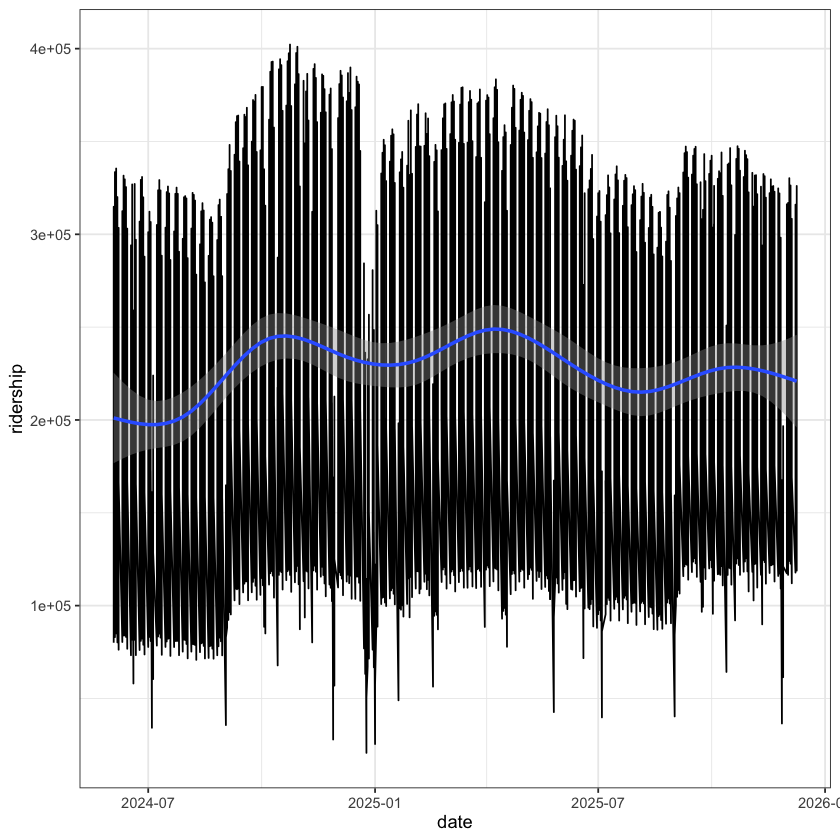

In [23]:
ggplot(data = df_daily, aes(x = date, y = ridership)) + geom_line() + theme_bw() +
geom_smooth()

## Regression by station

In [70]:
# random station
set.seed(99)

df |> filter(borough == "Queens") -> queens
queen_rows <- nrow(queens)
random_row <- sample(queen_rows, 1)

station <- queens[random_row, "station_complex"]

paste0("the random station selected in Queens was: ", station)

queens |> filter(station_complex == station) -> df_queens

head(df_queens)

[1] "the random station selected in Queens was: Middle Village-Metropolitan Av (M)"

,X,transit_timestamp,station_complex,borough,ridership,datetime,date,time
,<int>,<chr>,<chr>,<chr>,<dbl>,<dttm>,<date>,<chr>
1,83964,11/20/2024 10:00:00 AM,Middle Village-Metropolitan Av (M),Queens,17,2024-11-20 10:00:00,2024-11-20,10:00:00
2,83965,12/06/2024 05:00:00 PM,Middle Village-Metropolitan Av (M),Queens,14,2024-12-06 17:00:00,2024-12-06,17:00:00
3,83966,11/23/2024 05:00:00 AM,Middle Village-Metropolitan Av (M),Queens,8,2024-11-23 05:00:00,2024-11-23,05:00:00
4,83967,12/18/2024 02:00:00 PM,Middle Village-Metropolitan Av (M),Queens,11,2024-12-18 14:00:00,2024-12-18,14:00:00
5,83968,11/21/2024 09:00:00 AM,Middle Village-Metropolitan Av (M),Queens,32,2024-11-21 09:00:00,2024-11-21,09:00:00
6,83969,10/06/2024 09:00:00 AM,Middle Village-Metropolitan Av (M),Queens,23,2024-10-06 09:00:00,2024-10-06,09:00:00


In [71]:
df_queens |> mutate(
        transit_timestamp= trimws(transit_timestamp),
        datetime         = mdy_hms(transit_timestamp),
        date             = as.Date(datetime),
        time             = format(datetime, "%H:%M:%S"),
        ridership        = as.numeric(ridership)) -> df_queens

df_queens |> 
    group_by(date) |> 
    summarise(
        ridership = sum(ridership, na.rm = TRUE),
        .groups   = "drop") |>
    select(date, ridership) -> df_queens

head(df_queens)

date,ridership
<date>,<dbl>
2024-06-01,1414
2024-06-02,1068
2024-06-03,2337
2024-06-04,2674
2024-06-05,2545
2024-06-06,2407


In [73]:
colSums(is.na(df_queens))

date ridership 
        0         0

Don't really know why theres so many missing ridership values. Mildly concerning but I'm going to drop them. 

In [27]:
summary(df_rush)

   ridership           date            station_complex      borough         
 Min.   :  1.00   Min.   :2024-06-03   Length:6882664     Length:6882664    
 1st Qu.:  6.00   1st Qu.:2024-11-08   Class :character   Class :character  
 Median : 17.00   Median :2025-03-25   Mode  :character   Mode  :character  
 Mean   : 52.88   Mean   :2025-03-18                                        
 3rd Qu.: 44.00   3rd Qu.:2025-07-29                                        
 Max.   :999.00   Max.   :2025-12-09                                        
 NA's   :51684                                                              
     day           
 Length:6882664    
 Class :character  
 Mode  :character  
                   
                   
                   
                   

In [28]:
df_rush |> filter(!is.na(ridership)) -> df_rush

nrow(df_rush)

[1] 6830980

In [29]:
head(df_rush)

,ridership,date,station_complex,borough,day
,<int>,<date>,<chr>,<chr>,<chr>
1,6,2024-10-18,"Astoria-Ditmars Blvd (N,W)",Queens,Friday
2,30,2024-12-12,"Astoria-Ditmars Blvd (N,W)",Queens,Thursday
3,848,2024-11-04,"Astoria-Ditmars Blvd (N,W)",Queens,Monday
4,55,2024-11-22,"Astoria-Ditmars Blvd (N,W)",Queens,Friday
5,2,2024-11-06,"Astoria-Ditmars Blvd (N,W)",Queens,Wednesday
6,235,2024-12-16,"Astoria-Ditmars Blvd (N,W)",Queens,Monday


## CBD Boolean

By latitude/ longitude

 (scrapped)

<img src="/Users/Local/statsproject/pics/cbd_subway_coordbox.jpg" width="400" height="400">

In [30]:
# lat_high = 40.771372
# long_high= -74.00782 

# lat_low = 40.696999
# long_low = -73.966776 

In [31]:
# df$coords_cbd <- with(df, 
#    latitude >= lat_low & latitude <= lat_high & 
#    longitude <= long_low & longitude >= long_high)

Was the subway encoding close to the box one? 

In [32]:
# sum(df$coords_cbd == TRUE)

In [33]:
# sum(is.na(df$ridership))

# df <- drop_na(df, ridership)

## Checks

In [34]:
nrow(df_daily)

[1] 1588

In [35]:
n_distinct(df_daily$date)

[1] 397

In [ ]:
write.csv(df_daily, "data/clean/daily_ridership.csv", row.names = FALSE)

## Weather Data

Weather data from JFK International Airport reported on NOAA

Unit: Daily

https://www.ncdc.noaa.gov/cdo-web/ 

In [65]:
weather_df <- read.csv("data/supplemental/weather.csv")

head(weather_df)

dim(weather_df)

,STATION,NAME,DATE,PRCP,SNOW,SNWD,TMIN,WT01,WT02,WT03,WT04,WT06,WT08
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2024-06-01,0.00,0,0,62,NA,NA,NA,NA,NA,NA
2,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2024-06-02,0.00,0,0,62,NA,NA,NA,NA,NA,NA
3,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2024-06-03,0.02,0,0,66,NA,NA,NA,NA,NA,NA
4,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2024-06-04,0.00,0,0,64,1,1,NA,NA,NA,1
5,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2024-06-05,0.04,0,0,63,1,NA,NA,NA,NA,NA
6,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",2024-06-06,0.58,0,0,69,1,NA,NA,NA,NA,NA


[1] 579  13

In [66]:
weather_df |> 
    rename(
        min_temp = TMIN, 
        snow     = SNOW,
        snow_d   = SNWD,
        rain     = PRCP) |> 
    mutate(date = as.Date(DATE), format = "%m-%d-%Y") |> 
    select(date, min_temp, snow, snow_d, rain) -> weather_df

head(weather_df)

,date,min_temp,snow,snow_d,rain
,<date>,<int>,<dbl>,<dbl>,<dbl>
1,2024-06-01,62,0,0,0.00
2,2024-06-02,62,0,0,0.00
3,2024-06-03,66,0,0,0.02
4,2024-06-04,64,0,0,0.00
5,2024-06-05,63,0,0,0.04
6,2024-06-06,69,0,0,0.58


In [67]:
summary(weather_df)

      date               min_temp          snow             snow_d       
 Min.   :2024-06-01   Min.   :12.00   Min.   :0.00000   Min.   :0.00000  
 1st Qu.:2024-10-23   1st Qu.:38.00   1st Qu.:0.00000   1st Qu.:0.00000  
 Median :2025-03-17   Median :54.00   Median :0.00000   Median :0.00000  
 Mean   :2025-03-17   Mean   :51.42   Mean   :0.03592   Mean   :0.07049  
 3rd Qu.:2025-08-08   3rd Qu.:65.00   3rd Qu.:0.00000   3rd Qu.:0.00000  
 Max.   :2025-12-31   Max.   :81.00   Max.   :4.60000   Max.   :4.00000  
                                                        NA's   :3        
      rain        
 Min.   :0.00000  
 1st Qu.:0.00000  
 Median :0.00000  
 Mean   :0.08997  
 3rd Qu.:0.04000  
 Max.   :1.96000  
                  

In [68]:
colSums(is.na(weather_df))

date min_temp     snow   snow_d     rain 
       0        0        0        3        0

## Economic Data

scrapped

Unemployment rate data from NYC / Neward from FRED 

Unit: Monthly

https://fred.stlouisfed.org/series/NEWY636URN# 

In [38]:
# econ_df <- read.csv("/Users/Local/statsproject/data/supplemental/NEWY636URN.csv")

# econ_df |> 
#     mutate(month = as.Date(observation_date, format = "%Y-%m-%d"),
#           unemp = NEWY636URN) |> 
#    select(month, unemp) -> econ_df

# head(econ_df)

In [39]:
# sum(is.na(econ_df$unemp))

## Weekly aggregation

Mostly for noise reduction in the plots and stuff

In [40]:
df_rush |> 
    group_by(date, borough) |> 
    summarise(
        ridership = sum(ridership, na.rm = TRUE),
        .groups = "drop") |>
    select(date, borough, ridership) -> df_daily

In [41]:
# ref 5
df_daily |> 
    mutate(week = floor_date(date, "week")) |>
    group_by(week, borough)  |> 
    summarise(
        ridership = sum(ridership, na.rm = TRUE),
        .groups = "drop") -> df_weekly

In [42]:
head(df_weekly)

week,borough,ridership
<date>,<chr>,<int>
2024-06-02,Bronx,404496
2024-06-02,Brooklyn,1328534
2024-06-02,Manhattan,1607339
2024-06-02,Queens,873184
2024-06-09,Bronx,408117
2024-06-09,Brooklyn,1314784


In [ ]:
write.csv(df_weekly, "data/clean/weekly_ridership.csv", row.names = FALSE)

## Rolling average

3 day rolling average

In [61]:
# ref 5
df_smooth <- df_weekly |>
  arrange(borough, week) |>
  group_by(borough) |>
  mutate(rolling_avg = rollmean(ridership, k=3, fill = NA, align = "right"))

In [62]:
write.csv(df_weekly, "data/clean/smooth.csv", row.names = FALSE)

## Regression by station, joining weather

In [74]:
head(df_queens)

head(weather_df)

# head(econ_df)

date,ridership
<date>,<dbl>
2024-06-01,1414
2024-06-02,1068
2024-06-03,2337
2024-06-04,2674
2024-06-05,2545
2024-06-06,2407


,date,min_temp,snow,snow_d,rain
,<date>,<int>,<dbl>,<dbl>,<dbl>
1,2024-06-01,62,0,0,0.00
2,2024-06-02,62,0,0,0.00
3,2024-06-03,66,0,0,0.02
4,2024-06-04,64,0,0,0.00
5,2024-06-05,63,0,0,0.04
6,2024-06-06,69,0,0,0.58


In [75]:
# joins, ref 1
df_queens |> left_join(weather_df, by = "date") -> df_queens

head(df_queens)

write.csv(df_queens, "data/clean/queens.csv")

date,ridership,min_temp,snow,snow_d,rain
<date>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
2024-06-01,1414,62,0,0,0.00
2024-06-02,1068,62,0,0,0.00
2024-06-03,2337,66,0,0,0.02
2024-06-04,2674,64,0,0,0.00
2024-06-05,2545,63,0,0,0.04
2024-06-06,2407,69,0,0,0.58
